In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import sys

# Tell Python where your custom folder lives in Drive
folder_path = '/content/drive/MyDrive/Contrastive_Learning_Cifar-10'
if folder_path not in sys.path:
    sys.path.append(folder_path)

In [3]:
!pip install -q torch torchvision tqdm scikit-learn matplotlib

## 1. Import the modules
From here on, this notebook only calls functions defined in the `.py` files above.


In [4]:
import data, model, loss, train, evaluate, experiments
import torch, json
import matplotlib.pyplot as plt
import numpy as np

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Modules imported OK. Device:', DEVICE)

Modules imported OK. Device: cuda


## 2. Config

In [5]:
DATASET = 'cifar10'          
SUBSET_SIZE = 5000         #convenience default for fast iteration,
BATCH_SIZE = 256
EPOCHS = 10
TEMPERATURE = 0.5
EMBEDDING_DIM = 128
PROJECTION_DIM = 64
IN_CHANNELS = 1 if DATASET == 'mnist' else 3

## 3. Dataset sanity check
Calls `data.get_dataloaders` and visualizes a positive pair (two augmented views of the same image).

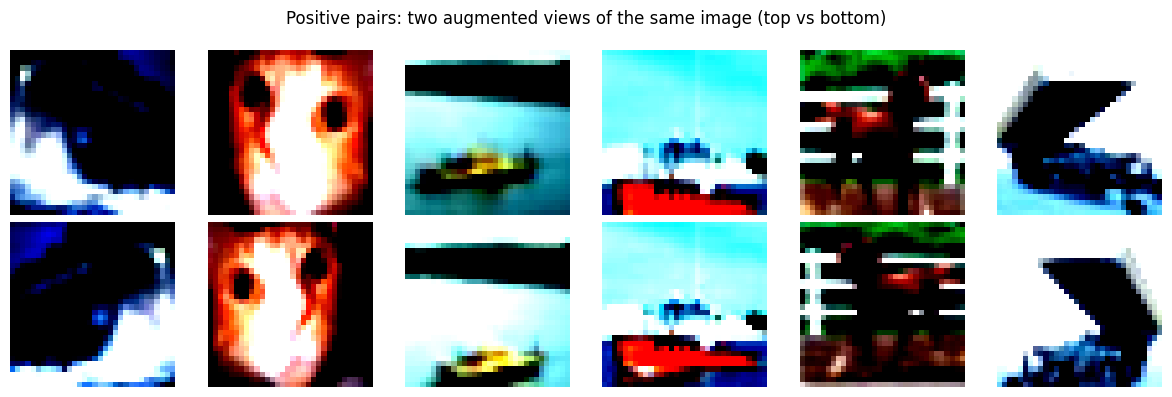

In [7]:
_probe_loader, _, _ = data.get_dataloaders(dataset=DATASET, strength='weak', batch_size=8, subset_size=200)
x1, x2, y = next(iter(_probe_loader))

fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for i in range(6):
    img1 = x1[i].permute(1, 2, 0).numpy() if IN_CHANNELS == 3 else x1[i, 0].numpy()
    img2 = x2[i].permute(1, 2, 0).numpy() if IN_CHANNELS == 3 else x2[i, 0].numpy()
    axes[0, i].imshow(img1, cmap='gray' if IN_CHANNELS == 1 else None); axes[0, i].axis('off')
    axes[1, i].imshow(img2, cmap='gray' if IN_CHANNELS == 1 else None); axes[1, i].axis('off')
fig.suptitle('Positive pairs: two augmented views of the same image (top vs bottom)')
plt.tight_layout(); plt.show()